In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Loading the Excel dataset

file_path = "../data/online_retail.csv"

df_2009 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

print("2009-2010:", df_2009.shape)
print("2010-2011:", df_2010.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [3]:
# Combine both years into one dataset

df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [6]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [7]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
# Check the important columns

df[["Invoice", "Quantity", "InvoiceDate", "Price", "Customer ID", "Country"]].head(10)

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [10]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 34335


In [11]:
# Remove transactions without Customer ID

df = df.dropna(subset=["Customer ID"])

print("Shape after removing missing Customer IDs:", df.shape)

Shape after removing missing Customer IDs: (824364, 8)


In [12]:
# Check cancelled invoices

df["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
False    805620
True      18744
Name: count, dtype: int64

In [13]:
# Keep only completed transactions

df = df[~df["Invoice"].astype(str).str.startswith("C")]

print("Shape after removing cancelled transactions:", df.shape)

Shape after removing cancelled transactions: (805620, 8)


In [14]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Price <= 0:", (df["Price"] <= 0).sum())

Quantity <= 0: 0
Price <= 0: 71


In [15]:
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

print("Shape after quantity/price cleaning:", df.shape)

Shape after quantity/price cleaning: (805549, 8)


In [16]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [17]:
df[["Quantity", "Price", "Revenue"]].head()
df["Revenue"].describe()

count    805549.000000
mean         22.026505
std         224.041928
min           0.001000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

In [18]:
# Number of unique customers

print("Unique customers:", df["Customer ID"].nunique())

Unique customers: 5878


In [19]:
# Number of unique invoices

print("Unique invoices:", df["Invoice"].nunique())

Unique invoices: 36969


In [20]:
# Total revenue

print("Total revenue:", df["Revenue"].sum())

Total revenue: 17743429.178000003


In [21]:
# Total quantity sold

print("Total quantity sold:", df["Quantity"].sum())

Total quantity sold: 10706167


In [22]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

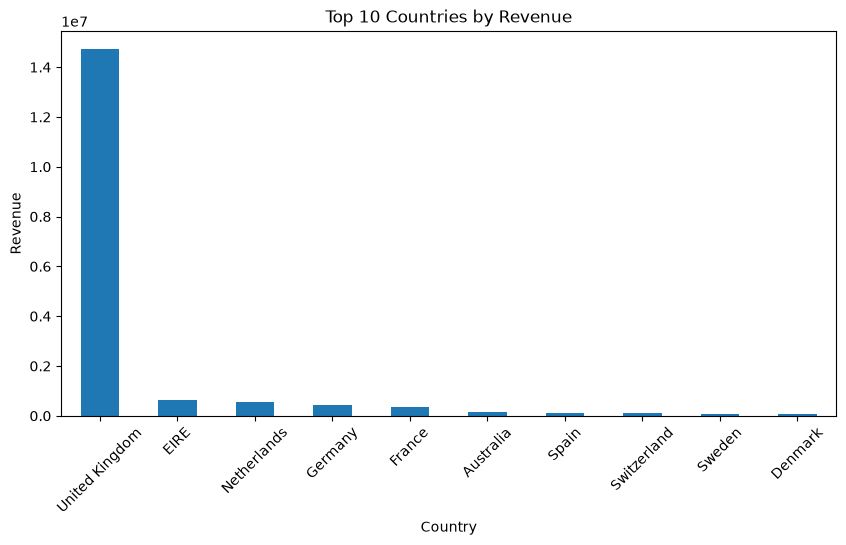

In [23]:
country_revenue.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Countries by Revenue"
)

plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.show()

In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [25]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
)

monthly_revenue.head()

Month
2009-12    686654.160
2010-01    557319.062
2010-02    506371.066
2010-03    699608.991
2010-04    594609.192
Freq: M, Name: Revenue, dtype: float64

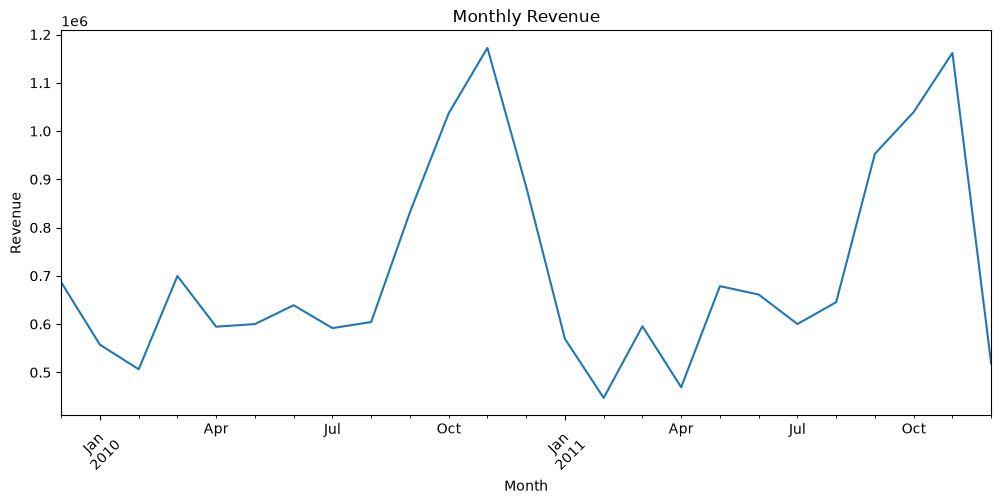

In [26]:
monthly_revenue.plot(
    figsize=(12, 5),
    title="Monthly Revenue"
)

plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

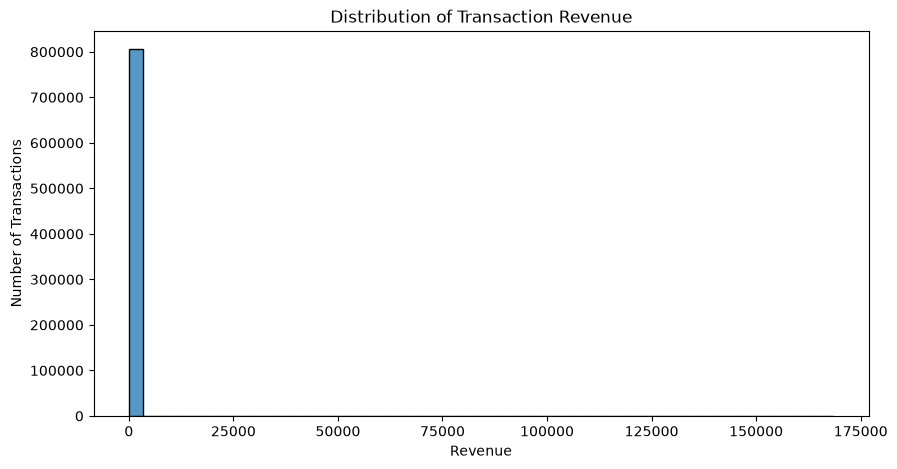

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Revenue"],
    bins=50
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.show()

In [28]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

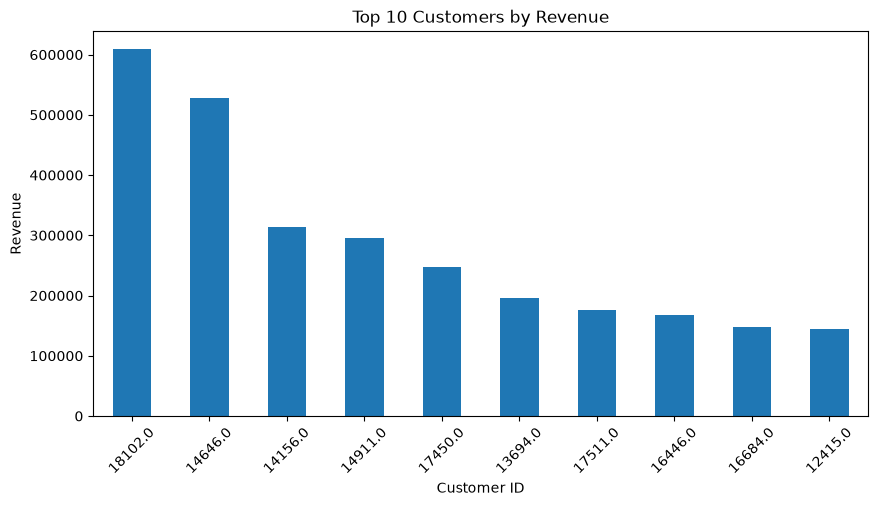

In [29]:
top_customers.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Customers by Revenue"
)

plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [30]:
# Reference date for calculating Recency

analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [31]:
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [32]:
print("Number of customers:", rfm.shape[0])
print("Number of RFM features:", rfm.shape[1])

Number of customers: 5878
Number of RFM features: 3


In [33]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [34]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 5878 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    5878 non-null   int64  
 1   Frequency  5878 non-null   int64  
 2   Monetary   5878 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 183.7 KB


In [35]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

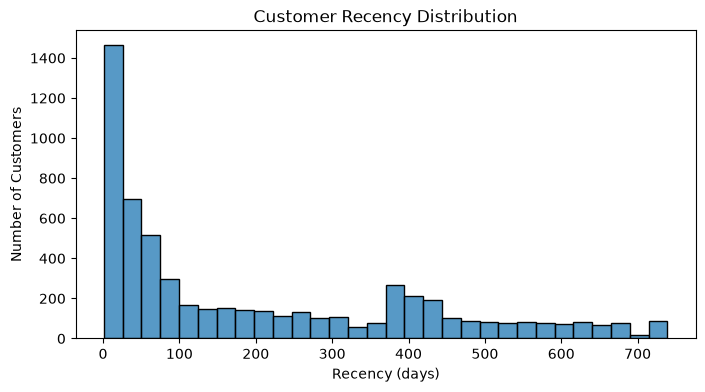

In [36]:
plt.figure(figsize=(8, 4))

sns.histplot(rfm["Recency"], bins=30)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("Number of Customers")

plt.show()

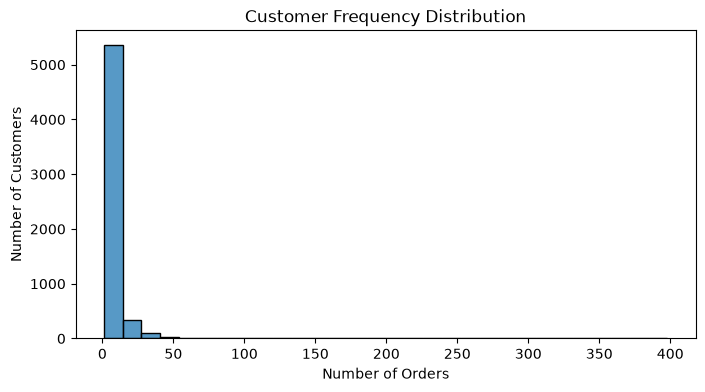

In [37]:
plt.figure(figsize=(8, 4))

sns.histplot(rfm["Frequency"], bins=30)

plt.title("Customer Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

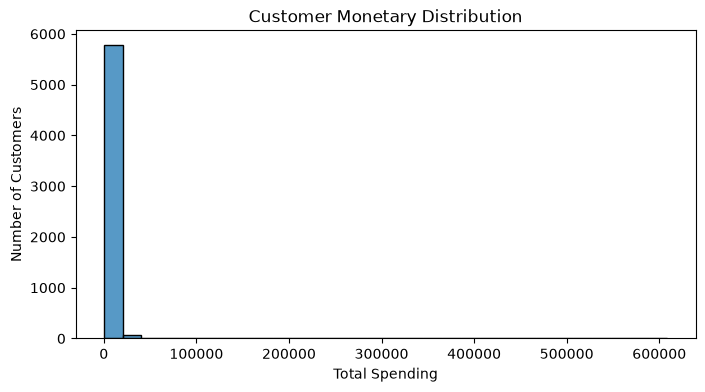

In [38]:
plt.figure(figsize=(8, 4))

sns.histplot(rfm["Monetary"], bins=30)

plt.title("Customer Monetary Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

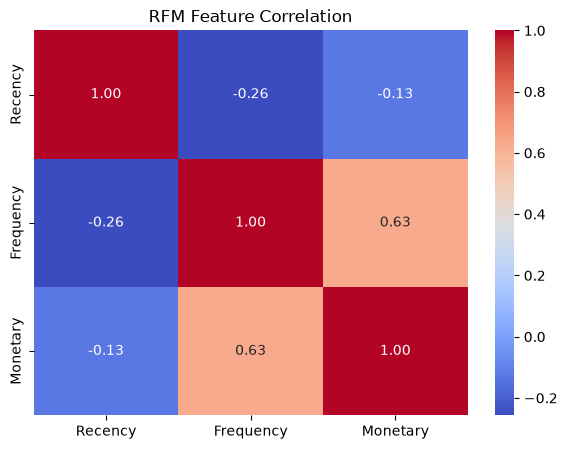

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("RFM Feature Correlation")

plt.show()

In [41]:
rfm_log = np.log1p(rfm)

In [42]:
rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,5.789960,2.564949,11.258774
12347.0,1.098612,2.197225,8.636632
12348.0,4.330733,1.791759,7.611051
12349.0,2.995732,1.609438,8.396085
12350.0,5.739793,0.693147,5.815324


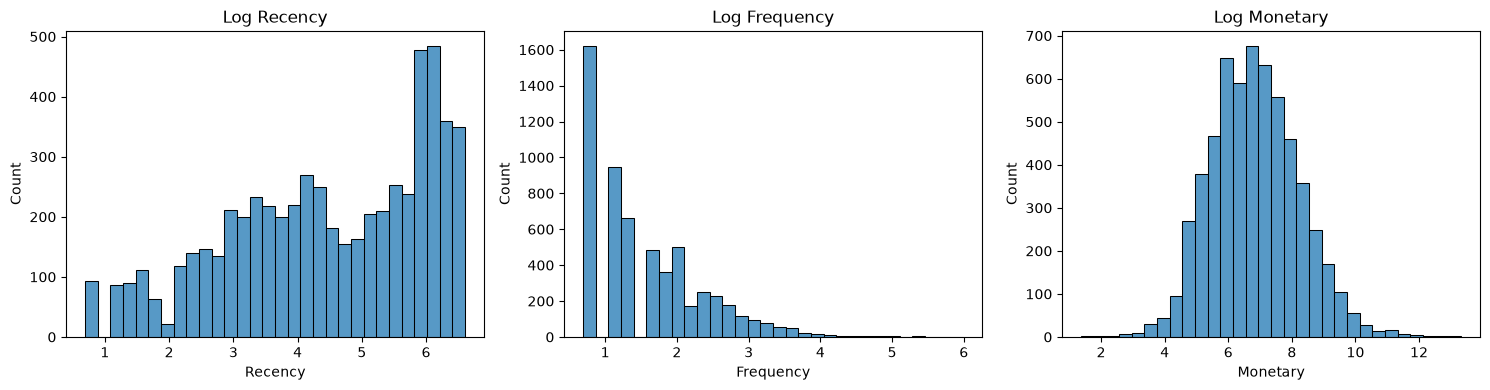

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm_log["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Log Recency")

sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Log Frequency")

sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Log Monetary")

plt.tight_layout()
plt.show()

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [45]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm.columns
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.856701,1.254496,3.186625
12347.0,-2.151979,0.800166,1.297127
12348.0,-0.079138,0.299207,0.558100
12349.0,-0.935308,0.073946,1.123790
12350.0,0.824527,-1.058146,-0.735888


In [46]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,-5.052856e-16,2.381370e-16,-4.351742e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.412014e+00,-1.058146e+00,-3.936481e+00
25%,-7.428435e-01,-1.058146e+00,-7.056734e-01
50%,7.733065e-02,-2.017514e-01,-2.467978e-02
75%,9.547202e-01,6.546432e-01,6.540289e-01
max,1.380464e+00,5.484918e+00,4.671413e+00


In [47]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

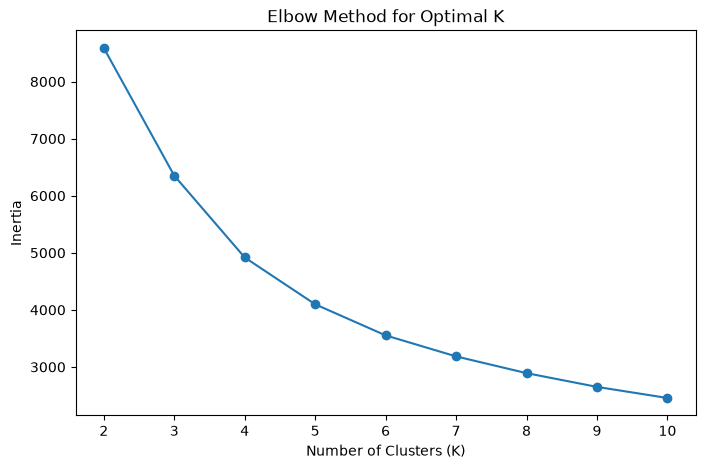

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))
plt.show()

In [49]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    
    silhouette_scores.append(score)

In [52]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

k_values = range(2, 11)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

print("K values:", list(k_values))
print("Number of scores:", len(silhouette_scores))


K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of scores: 9


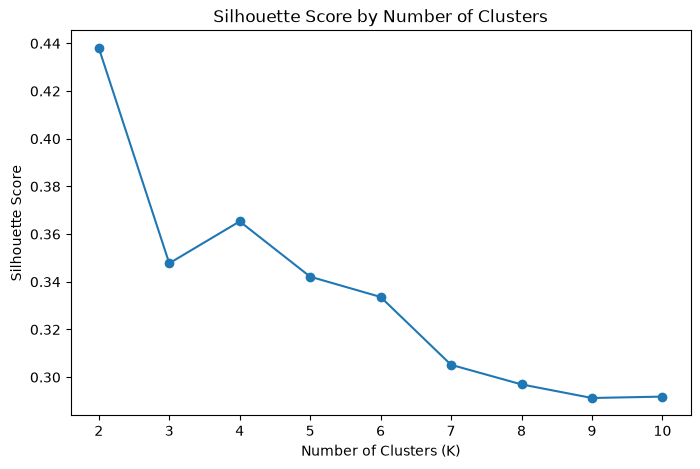

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.show()

In [54]:
for k, score in zip(k_values, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

K=2: Silhouette Score=0.4381
K=3: Silhouette Score=0.3478
K=4: Silhouette Score=0.3653
K=5: Silhouette Score=0.3421
K=6: Silhouette Score=0.3336
K=7: Silhouette Score=0.3052
K=8: Silhouette Score=0.2970
K=9: Silhouette Score=0.2913
K=10: Silhouette Score=0.2918


In [55]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [56]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    1188
1    1974
2    1465
3    1251
Name: count, dtype: int64


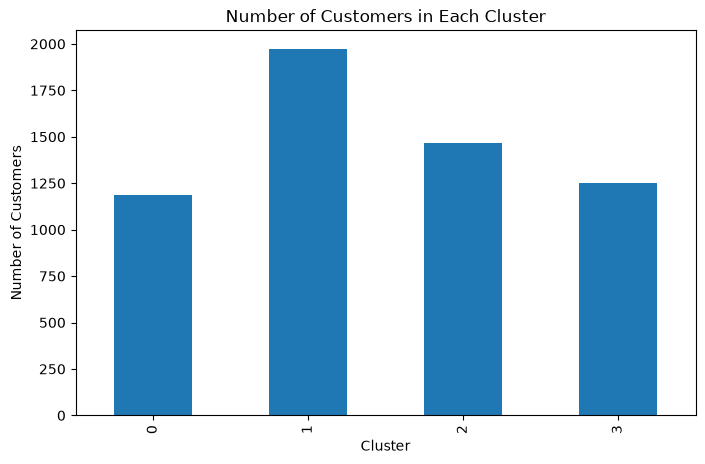

In [57]:
cluster_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Number of Customers in Each Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [58]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Recency", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,1188,27.43,19.34,11014.37
1,1974,395.86,1.38,325.75
2,1465,227.87,5.10,2002.10
3,1251,28.44,3.04,865.11


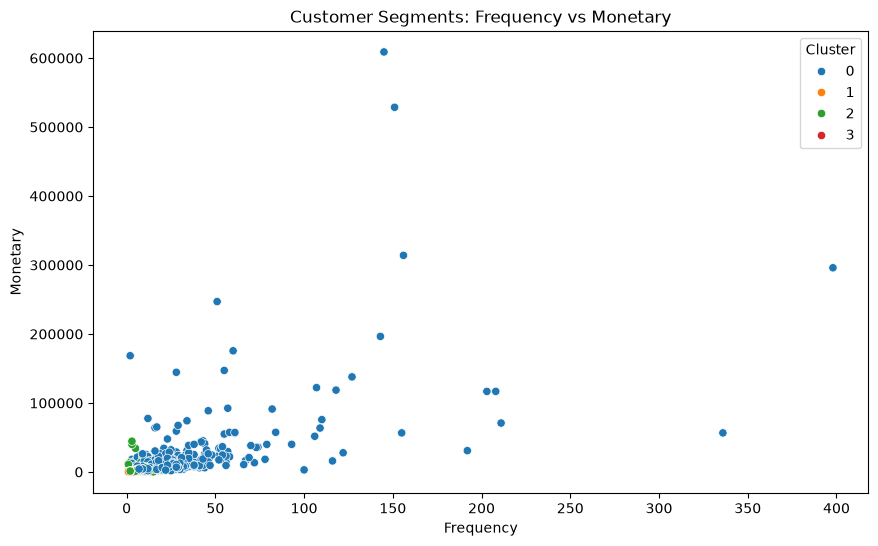

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

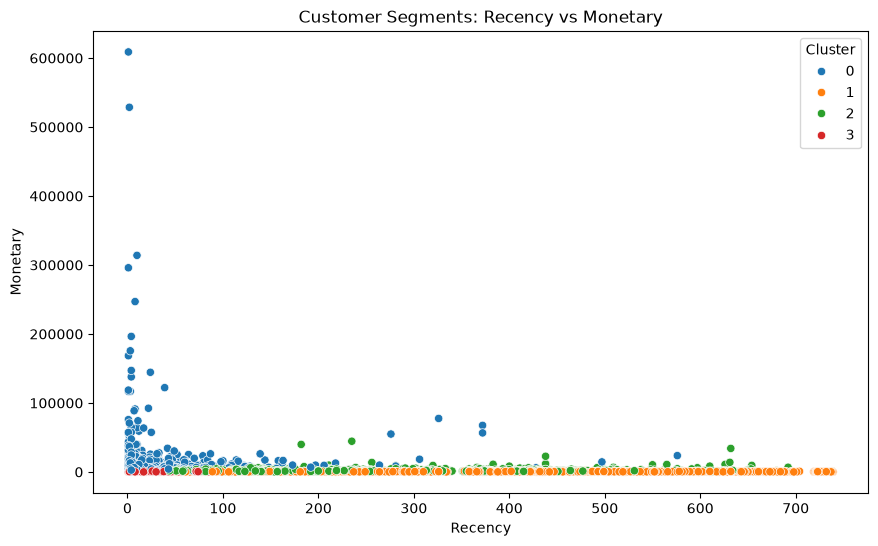

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

In [61]:
segment_summary = rfm.groupby("Cluster").agg(
    Customer_Count=("Cluster", "count"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Orders=("Frequency", "mean"),
    Avg_Spending=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

segment_summary

,Customer_Count,Avg_Recency_Days,Avg_Orders,Avg_Spending,Total_Revenue
Cluster,,,,,
0,1188,27.43,19.34,11014.37,13085069.69
1,1974,395.86,1.38,325.75,643026.91
2,1465,227.87,5.10,2002.10,2933080.13
3,1251,28.44,3.04,865.11,1082252.45


In [62]:
segment_summary.sort_values(
    "Avg_Spending",
    ascending=False
)

,Customer_Count,Avg_Recency_Days,Avg_Orders,Avg_Spending,Total_Revenue
Cluster,,,,,
0,1188,27.43,19.34,11014.37,13085069.69
2,1465,227.87,5.10,2002.10,2933080.13
3,1251,28.44,3.04,865.11,1082252.45
1,1974,395.86,1.38,325.75,643026.91


In [ ]:
rfm.to_csv(
    "../data/customer_rfm_segments.csv"
)

print("RFM segmentation dataset saved successfully")

RFM segmentation dataset saved successfully!


In [64]:
best_k = list(k_values)[np.argmax(silhouette_scores)]

print("Best K based on silhouette score:", best_k)

Best K based on silhouette score: 2


In [65]:
for k, score in zip(k_values, silhouette_scores):
    print(f"K={k}: {score:.4f}")

K=2: 0.4381
K=3: 0.3478
K=4: 0.3653
K=5: 0.3421
K=6: 0.3336
K=7: 0.3052
K=8: 0.2970
K=9: 0.2913
K=10: 0.2918


In [66]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = final_kmeans.fit_predict(rfm_scaled)

print("Final clustering completed!")

Final clustering completed!


In [68]:
print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    2352
1    3526
Name: count, dtype: int64


In [69]:
segment_profile = rfm.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,
0,2352,51.15,12.59,6619.45,15568957.61
1,3526,301.51,2.09,616.70,2174471.56


In [71]:
segment_profile.sort_values(
    "Avg_Monetary",
    ascending=False
)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,
0,2352,51.15,12.59,6619.45,15568957.61
1,3526,301.51,2.09,616.70,2174471.56


In [83]:
segment_profile["Customer_Percentage"] = (
    segment_profile["Customers"]
    / segment_profile["Customers"].sum()
    * 100
).round(2)

segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Percentage
Cluster,,,,,,
0,2352,51.15,12.59,6619.45,15568957.61,40.01
1,3526,301.51,2.09,616.70,2174471.56,59.99


In [84]:
segment_names = {
    0: "High-Value Loyal Customers",
    1: "At-Risk / Low-Engagement Customers"
}

rfm_final = rfm.copy()

rfm_final["Segment"] = rfm_final["Cluster"].map(segment_names)

rfm_final.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,0,High-Value Loyal Customers
12347.0,2,8,5633.32,0,High-Value Loyal Customers
12348.0,75,5,2019.40,0,High-Value Loyal Customers
12349.0,19,4,4428.69,0,High-Value Loyal Customers
12350.0,310,1,334.40,1,At-Risk / Low-Engagement Customers


In [85]:
rfm_final.reset_index().to_csv(
    "../data/customer_rfm_segments.csv",
    index=False
)

In [86]:
rfm_final.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,0,High-Value Loyal Customers
12347.0,2,8,5633.32,0,High-Value Loyal Customers
12348.0,75,5,2019.40,0,High-Value Loyal Customers
12349.0,19,4,4428.69,0,High-Value Loyal Customers
12350.0,310,1,334.40,1,At-Risk / Low-Engagement Customers


In [73]:
segment_profile.sort_values("Avg_Monetary", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Percentage
Cluster,,,,,,
0,2352,51.15,12.59,6619.45,15568957.61,40.01
1,3526,301.51,2.09,616.70,2174471.56,59.99


In [87]:
rfm_final["Segment"].value_counts()

Segment
At-Risk / Low-Engagement Customers    3526
High-Value Loyal Customers            2352
Name: count, dtype: int64

In [74]:
rfm_final = rfm.copy()

In [88]:
joblib.dump(scaler, "../models/rfm_scaler.pkl")
joblib.dump(final_kmeans, "../models/customer_segmentation_kmeans.pkl")

['../models/customer_segmentation_kmeans.pkl']

In [75]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.76372366 0.18766172]
Total explained variance: 0.9513853732999129


In [89]:
rfm_final = rfm_final.join(
    pca_df[["PCA1", "PCA2"]]
)

In [76]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PCA1", "PCA2"],
    index=rfm.index
)

pca_df["Cluster"] = rfm["Cluster"]

pca_df.head()

,PCA1,PCA2,Cluster
Customer ID,,,
12346.0,2.266512,2.432228,0
12347.0,2.362442,-1.074868,0
12348.0,0.561605,0.252426,0
12349.0,1.195893,-0.315647,0
12350.0,-1.513368,0.089933,1


In [90]:
rfm_final.reset_index().to_csv(
    "../data/customer_rfm_segments.csv",
    index=False
)

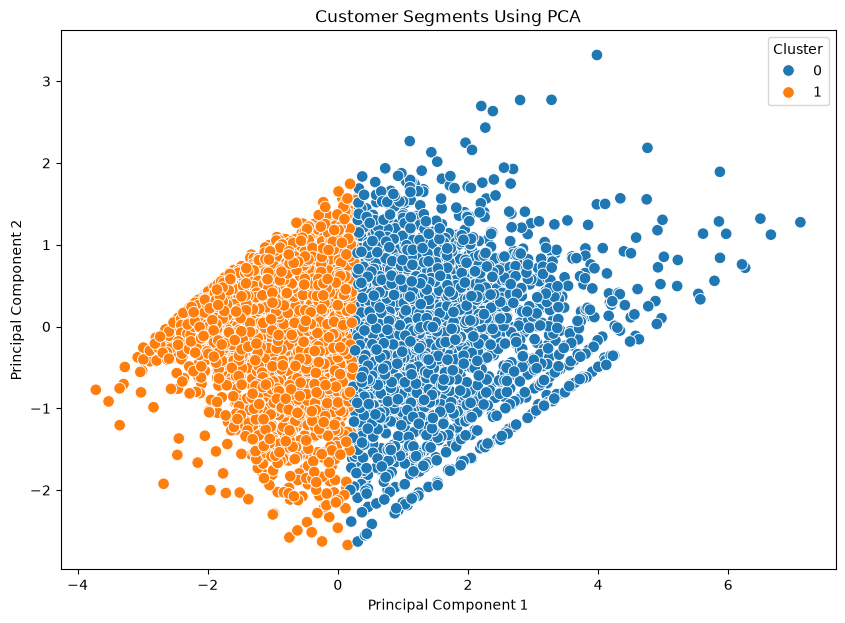

In [77]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    s=70
)

plt.title("Customer Segments Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [91]:
rfm_final.columns

Index(['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'PCA1',
       'PCA2'],
      dtype='str')

In [78]:
rfm_final.to_csv(
    "../data/customer_rfm_segments.csv"
)

print("Final segmentation saved successfully!")

Final segmentation saved successfully!


In [79]:
import joblib

In [80]:
joblib.dump(
    scaler,
    "../models/rfm_scaler.pkl"
)

['../models/rfm_scaler.pkl']

In [81]:
joblib.dump(
    final_kmeans,
    "../models/customer_segmentation_kmeans.pkl"
)

['../models/customer_segmentation_kmeans.pkl']

In [82]:
print("Scaler and K-Means model saved successfully!")

Scaler and K-Means model saved successfully!
